<a href="https://colab.research.google.com/github/EstebanBotero03/Senalesysistemas/blob/main/parcial_1_se%C3%B1ales%20corregido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ESTEBAN BOTERO OROZCO**
PARCIAL #1
SEÑALES Y SISTEMAS

PUNTO 1

### Importación de librerías necesarias

- `numpy`: para operaciones matemáticas y manejo de arrays.
- `matplotlib.pyplot`: para graficar.
- `cdist` de `scipy.spatial.distance`: para calcular distancias entre vectores (usado en la cuantización).
### Definición de la señal analógica original

Se define una señal compuesta:

$$[
x(t) = 20 \sin(7t - \frac{\pi}{2}) - 3 \cos(5t) + 2 \cos(10t)
]$$

- `Fo` es la frecuencia fundamental.
- `To` es el período fundamental \( 2\pi \).
- `Fs` es la frecuencia de muestreo (10 veces mayor que la frecuencia fundamental) para cumplir con el criterio de Nyquist.
- `tv` es el vector de tiempo discreto desde 0 hasta dos períodos de la señal.
- `y` es la señal evaluada en los tiempos definidos.
### Aplicación de la función de cero y pendiente

La función `my_ceropen` realiza un escalamiento lineal (normalización con cero y pendiente) de la señal `y`, para que sus valores queden en el rango definido entre `ymin = -3.3` y `ymax = 5`.

Esto es necesario para adaptar la señal al rango de entrada de un conversor A/D.
### Parámetros de cuantización

- `nbits = 5`: se define un convertidor de 5 bits, lo que significa que se puede representar \( 2^5 = 32 \) niveles diferentes.
- `rmin` y `rmax` son los valores mínimo y máximo del rango de cuantización, que deben coincidir con los usados en la normalización.
- `ve` es el vector de niveles de cuantización, generados uniformemente entre `rmin` y `rmax`.
### Cálculo de distancias entre muestras normalizadas y niveles de cuantización

Se usa `cdist` para calcular la **distancia euclidiana** entre cada muestra de la señal `ycs` y cada nivel del vector `ve`.

- `ycs.reshape(-1, 1)`: convierte el vector de muestras a una columna (necesario para `cdist`).
- `ve.reshape(-1, 1)`: convierte el vector de niveles de cuantización a una columna.

Esto permite determinar qué nivel está más cerca de cada muestra.


In [1]:
def my_ceropen(x,ymin = -3.3, ymax = 5): #en general se pueden definir valores por defecto
  '''
  Codigo base para simular proceso de cero y pendiente
  Se ingresa arreglo de numpy y los valores min  y max despues de cero y pendiente
  '''
  xmax = max(x) # x.max()
  xmin = min(x) # x.min()
  m = (ymax - ymin)/(xmax - xmin)
  c = ymin - m*xmin
  yv = m*x + c
  return yv
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# señal original
Fo = 1/(2*np.pi)
To = 2*np.pi
Fs = 10 * np.pi  # asegurar Nyquist
Ts = 1 / Fs
tv = np.arange(0, 2 * To, Ts)  # procesar dos periodos discretizados
y = 20 * np.sin(7 * tv - np.pi/2) - 3 * np.cos(5 * tv) + 2 * np.cos(10 * tv)

# cero y pendiente
ycs = my_ceropen(y, ymin=-3.3,ymax=5)

# número de bits y vector de cuantización
nbits = 5
rmin = -3.3
rmax = 5
ve = np.linspace(rmin, rmax, 2**nbits)  # 32 niveles

# distancias y cero pendiente a vector de cuantización
d = cdist(ycs.reshape(-1, 1), ve.reshape(-1, 1))  # reshape para vectores columna
d.shape  # d es una matriz con distancias entre cada muestra y cada nivel de cuantización


(395, 32)

### Identificación del nivel de cuantización más cercano

- `np.argmin(d, axis=1)` devuelve, para cada muestra, el índice del nivel de cuantización más cercano.
- `axis=1` indica que se busca el valor mínimo a lo largo de las **columnas** de la matriz `d`, es decir, se busca el nivel (`ve[j]`) más cercano a cada muestra (`ycs[i]`).

El resultado `ind` es un vector de índices que indica qué nivel de `ve` se asigna a cada muestra para formar la señal cuantizada.


In [2]:
#se requiere identificar el elemento ve[j] más cercano a y[i] para generar señal cuantizada
ind = np.argmin(d, axis=1) #el parámetro axis = 1 indica que busca la posición a lo largo de las columnas del elemento más pequeño en cada fila
ind


array([ 1,  1,  2,  3,  5,  7, 10, 13, 16, 19, 21, 24, 26, 28, 29, 29, 29,
       28, 26, 24, 21, 18, 15, 12,  9,  6,  4,  2,  1,  1,  1,  2,  4,  7,
       10, 13, 16, 19, 21, 24, 25, 26, 27, 26, 25, 24, 22, 19, 17, 14, 12,
        9,  7,  6,  5,  4,  4,  4,  6,  7,  9, 11, 13, 15, 18, 20, 22, 24,
       25, 26, 26, 26, 25, 24, 23, 20, 18, 15, 13, 10,  7,  5,  3,  1,  0,
        0,  1,  2,  4,  6,  9, 12, 16, 19, 23, 26, 28, 30, 31, 31, 30, 29,
       27, 24, 21, 17, 14, 10,  7,  5,  2,  1,  0,  0,  1,  2,  4,  6,  9,
       12, 14, 17, 20, 22, 24, 25, 26, 26, 26, 25, 24, 23, 21, 19, 16, 14,
       12, 10,  8,  6,  5,  4,  4,  4,  5,  7,  8, 11, 13, 16, 18, 21, 23,
       25, 26, 27, 27, 26, 24, 22, 20, 17, 14, 11,  8,  5,  3,  2,  1,  1,
        1,  3,  5,  8, 11, 14, 17, 20, 23, 25, 27, 28, 29, 29, 28, 27, 25,
       22, 20, 17, 14, 11,  8,  6,  4,  2,  1,  1,  1,  2,  3,  4,  7,  9,
       12, 15, 17, 20, 23, 25, 27, 28, 29, 29, 28, 27, 25, 22, 19, 16, 13,
       10,  7,  4,  2,  1

### Verificación del nivel de cuantización asignado a una muestra específica

Esta línea imprime:

- `ycs[1]`: el valor normalizado de la segunda muestra de la señal (recordando que los índices inician en 0).
- `ind[1]`: el índice del nivel de cuantización más cercano a `ycs[1]`, obtenido previamente con `np.argmin`.
- `ve[ind[1]]`: el valor real del nivel cuantizado asignado a `ycs[1]`.

Esto permite verificar que el proceso de cuantización asigna correctamente el nivel más cercano a cada muestra.


In [3]:
print(ycs[1], ind[1], ve[ind[1]])  # para ycs[1], el nivel cuantizado más cercano es ve[ind[1]]


-2.9888445908669117 1 -3.032258064516129


### Función `my_cuantizador`: Cuantización de un solo valor

Esta función toma un valor y lo cuantiza al nivel más cercano en un conjunto de niveles predefinidos.

#### Parámetros:
- `yn`: valor numérico a cuantizar (escalar).
- `vq`: vector de niveles de cuantización (por ejemplo, `ve` con 32 niveles uniformes).

#### Proceso interno:
1. `vq.shape[0]`: obtiene el número total de niveles.
2. `yn.reshape(-1, 1)` y `vq.reshape(-1, 1)`: convierten los valores en vectores columna para usarlos con `cdist`.
3. `cdist(...)`: calcula la distancia entre `yn` y cada nivel de `vq`.
4. `np.argmin(dn)`: encuentra el índice del nivel más cercano.
5. `vq[ind]`: retorna el valor cuantizado correspondiente al índice más cercano.

Esta función se puede usar dentro de un bucle para cuantizar una señal muestra por muestra.


In [4]:
#función cuantización punto a punto

def my_cuantizador(yn, vq):  # yn punto a cuantizar, vq vector de niveles de cuantización
  Ne = vq.shape[0]  # tamaño del vector de niveles
  dn = cdist(yn.reshape(-1,1), vq.reshape(-1,1))  # distancia entre el punto y los niveles
  ind = np.argmin(dn)  # posición del nivel más cercano
  return vq[ind]


### Cuantización de toda la señal mediante recorrido muestra por muestra

Se recorre el vector `ycs` (la señal normalizada con cero y pendiente) para cuantizar cada una de sus muestras.

#### Paso a paso:
- Se utiliza un bucle `for` para iterar sobre cada muestra de `ycs`.
- En la primera iteración (`i == 0`), se inicializa el vector `yq` con la primera muestra cuantizada.
- En las siguientes iteraciones (`i > 0`), se usa `np.append` para ir acumulando las muestras cuantizadas en el vector `yq`.

> Nota: Este método es didáctico pero **no es el más eficiente** computacionalmente. Para señales largas, es mejor usar una versión vectorizada.


In [5]:
#recorrer vector cero y pendiente discretizado para cuantizar

for i in range(ycs.shape[0]):
   if i == 0:  # primera muestra
     yq = my_cuantizador(ycs[i], ve)
   else:
     yq = np.append(yq, my_cuantizador(ycs[i], ve))  # apilar datos cuantizados si i > 0


### Visualización del proceso completo de digitalización

Esta gráfica muestra todas las etapas clave del proceso de conversión de una señal analógica a digital:

- `plt.plot(tv, ycs, c='r', label='ycs')`: traza la señal continua acondicionada (`ycs`) en rojo.
- `plt.stem(tv, ycs, label='ycs_dis')`: representa las muestras discretas de la señal acondicionada, con líneas y marcadores, simulando la muestreo temporal.
- `for v in ve: ...`: se dibujan líneas horizontales para cada uno de los niveles de cuantización definidos en `ve`. Estas líneas representan los posibles estados de cuantización que puede tomar la señal digital.
- `plt.plot(tv, yq, c='y', marker='o', label='ydig', linewidth=2)`: representa la señal digital resultante (`yq`), es decir, cuantizada y discretizada. Se muestra en color amarillo con círculos marcando los puntos cuantizados.

#### Detalles adicionales:
- `plt.legend()`: agrega una leyenda para identificar cada señal.
- `plt.grid()`: muestra una cuadrícula para facilitar la lectura.
- `plt.xlabel('t') / plt.ylabel('Amplitud')`: etiquetas de los ejes.
- `plt.show()`: despliega la figura final.

Este gráfico ilustra claramente cómo se transforma una señal continua en una señal digital mediante acondicionamiento, muestreo y cuantización.


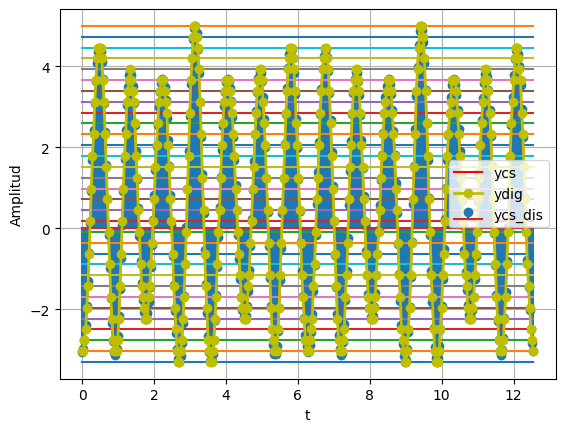

In [6]:
#graficar señales

plt.plot(tv, ycs, c='r', label='ycs')  # señal continua acondicionada

plt.stem(tv, ycs, label='ycs_dis')  # señal acondicionada discreta

# estados de cuantización

for v in ve:
  plt.plot(tv, v*np.ones(len(tv)))  # líneas de niveles de cuantización

# graficar señal Digital (discreta + cuantizada)

plt.plot(tv, yq, c='y', marker='o', label='ydig', linewidth=2)

plt.legend()
plt.grid()
plt.xlabel('t')
plt.ylabel('Amplitud')
plt.show()


PUNTO 2

### Importación de librerías necesarias

- `numpy`: se usa para operaciones matemáticas y manipulación de arreglos numéricos.
- `matplotlib.pyplot`: se utiliza para crear gráficos y visualizar señales.
- `scipy.signal.convolve`: permite aplicar operaciones de convolución, útiles por ejemplo para filtros digitales o reconstrucción de señales.
- `scipy.spatial.distance.cdist`: calcula matrices de distancias entre dos conjuntos de vectores, fundamental en el proceso de cuantización para determinar el nivel más cercano a cada muestra.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
from scipy.spatial.distance import cdist


### Visualización de la señal original continua x(t)

Este bloque genera y grafica la señal analógica compuesta:

\[
x(t) = 3\cos(1000\pi t) + 5\sin(2000\pi t) + 10\cos(11000\pi t)
\]

#### Detalles del código:
- `t = np.linspace(0, 0.006, 10000)`: genera un vector de tiempo desde 0 hasta 6 ms, con 10,000 muestras, para una resolución temporal fina.
- `x_t`: define la señal combinando tres componentes sinusoidales con diferentes frecuencias y amplitudes.
- `plt.plot(...)`: grafica la señal en función del tiempo.
- Se agregan título, etiquetas de ejes, cuadrícula y leyenda para interpretar correctamente la gráfica.

Esta señal es continua y se usará como base para analizar el efecto de la muestreo y cuantización en el proceso de conversión a digital.


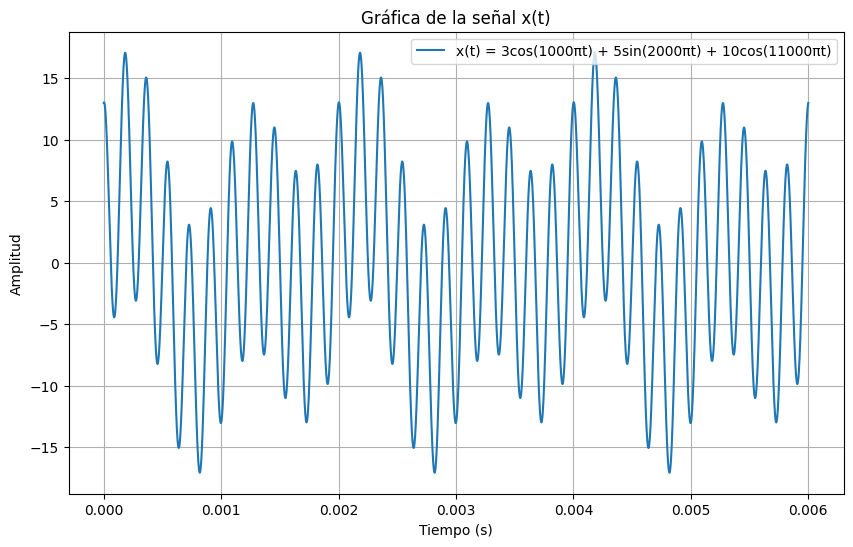

In [8]:
# Se grafica la señal original
t = np.linspace(0, 0.006, 10000)  # Se define t y damos valor al intervalo de tiempo a graficar

# Se define x_t como la señal a trabajar
x_t = 3*np.cos(1000*np.pi*t) + 5*np.sin(2000*np.pi*t) + 10*np.cos(11000*np.pi*t)

# Se grafica la señal x(t)
plt.figure(figsize=(10, 6))  # Tamaño de la figura
plt.plot(t, x_t, label='x(t) = 3cos(1000πt) + 5sin(2000πt) + 10cos(11000πt)')
plt.title('Gráfica de la señal x(t)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()


### Función `muestrear_y_graficar`: Muestreo y visualización de una señal

Esta función permite simular el muestreo de una señal continua y graficar su versión discretizada en el dominio del tiempo.

#### Parámetros:
- `fs`: frecuencia de muestreo en Hz (por ejemplo, 5000 para 5 kHz).
- `duracion`: duración total de la señal en segundos (por defecto, 6 ms).
- `titulo`: texto para el título de la gráfica generada.

#### Dentro de la función:
- `T = 1/fs`: se calcula el período de muestreo.
- `t = np.arange(0, duracion, T)`: se crea un vector de tiempo con pasos iguales al período de muestreo, simulando los instantes en los que se toman las muestras.
- Se genera la señal muestreada evaluando \( x(t) = 3\cos(1000\pi t) + 5\sin(2000\pi t) + 10\cos(11000\pi t) \) en esos puntos discretos.
- `plt.stem(...)`: se utiliza para graficar la señal de forma discreta (líneas verticales con marcadores).

Esta función es útil para estudiar los efectos de diferentes frecuencias de muestreo sobre la representación de la señal original.


In [9]:
# Se crea una función para muestrear y graficar nuestra señal
def muestrear_y_graficar(fs, duracion=0.006, titulo=''):
    """
    Muestra y grafica la señal x_t, utilizando la frecuencia de muestreo de 5kHz.

    Especificación de los parámetros:
    - fs: Frecuencia de muestreo en Hz.
    - duracion: Duración de la señal en segundos para la simulación.
    - titulo: Título para la gráfica de la señal.
    """
    T=1/fs
    t = np.arange(0, duracion, T)  # Vector de tiempo

    # Señal
    x_t = 3*np.cos(1000*np.pi*t) + 5*np.sin(2000*np.pi*t) + 10*np.cos(11000*np.pi*t)


    plt.figure(figsize=(10, 6))
    plt.stem(t, x_t, linefmt='b-', markerfmt="bo", basefmt="k")
    plt.title(titulo)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.show()


### Muestreo y gráfica de la señal a 5 kHz

Se llama a la función `muestrear_y_graficar` con una frecuencia de muestreo de 5000 Hz para obtener la señal discretizada y mostrar su gráfica correspondiente.

Esto permite visualizar cómo la señal original es representada mediante muestras tomadas cada 0.2 ms.


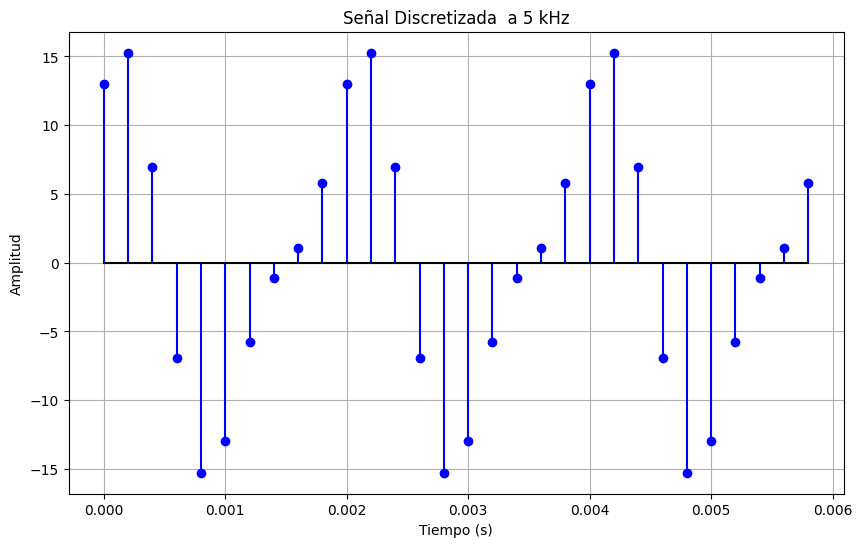

In [10]:
# Se grafica la señal muestreada a 5KHz
muestrear_y_graficar(5000, titulo='Señal Discretizada  a 5 kHz')


Como la frecuencia de muestreo de 5 kHz no cumple con el criterio establecido por el teorema de Nyquist —ya que es inferior al doble de la frecuencia más alta presente en la señal (5500 Hz)—, no es adecuada para digitalizar esta señal correctamente. Utilizar esta frecuencia implicaría la aparición de aliasing, es decir, una distorsión en la señal digitalizada.
Por ello, se selecciona una nueva frecuencia de muestreo de 11 kHz, que sí supera el mínimo necesario y garantiza una representación fiel de la señal original.



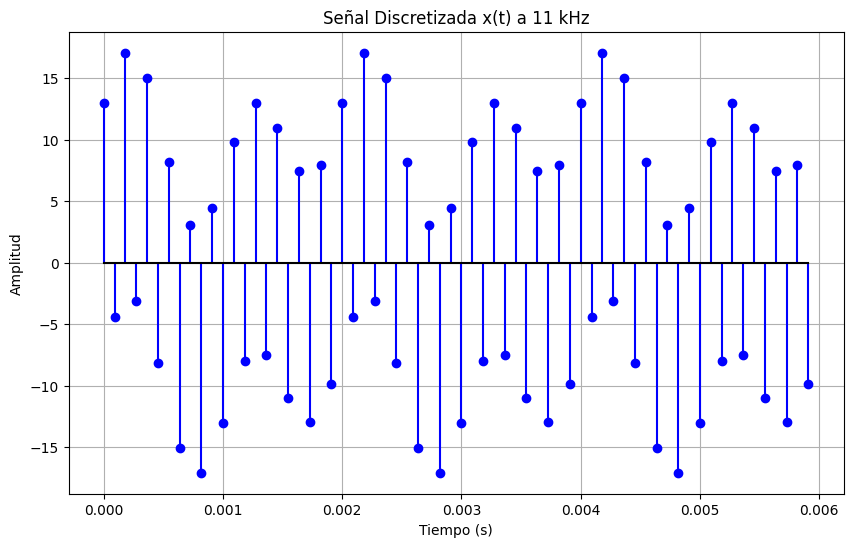

In [11]:
muestrear_y_graficar(11000, titulo='Señal Discretizada x(t) a 11 kHz')


PUNTO 3


Este código calcula una medida que nos indica qué tan diferentes son dos señales a lo largo del tiempo, usando la potencia media y el límite cuando el periodo tiende a infinito.

1. Primero definimos variables simbólicas:
   - $T_0$: el período total de la señal.
   - $t$: la variable de tiempo.
   - $A$: la amplitud de la señal cosenoidal.

2. Calculamos la frecuencia angular como:
   
$$
\omega_0 = \frac{2\pi}{T_0}
$$

3. Definimos una función llamada `potencia_media` que calcula la integral del cuadrado de una señal en un intervalo dado, esto representa la potencia media en ese intervalo.

4. Definimos dos señales:
   - $x_1(t) = A \cos(\omega_0 t)$, una señal cosenoidal.
   - $x_2(t)$, una señal definida por partes que vale 1 en el primer cuarto del periodo, -1 en la mitad siguiente, y 1 en el último cuarto.

5. Calculamos la potencia media de cada señal en un período completo $[0, T_0]$ usando la función `potencia_media`.

6. Calculamos la potencia cruzada entre ambas señales integrando el producto $x_1(t) x_2(t)$ en el mismo intervalo. Esto mide la similitud entre ambas señales.

7. Finalmente, calculamos la distancia media entre las señales como:

$$
d = \lim_{T_0 \to \infty} \frac{1}{T_0} \int_0^{T_0} |x_1(t) - x_2(t)|^2 dt = \lim_{T_0 \to \infty} \left(P_{x_1} + P_{x_2} - 2 \times \text{potencia cruzada} \right)
$$

Esta fórmula nos da un valor que representa cuán distintas son las dos señales en promedio a lo largo del tiempo.

El código usa la librería SymPy para calcular todas estas integrales y límites simbólicamente.

Así podemos obtener una medida matemática precisa de la diferencia entre estas dos señales en todo su dominio temporal.




In [12]:
from sympy import Symbol, limit, oo
import sympy as sp

# Declarar los símbolos
T0, t, A = sp.symbols('T0 t A', real=True)

# Definir la frecuencia angular
W0 = (2 * sp.pi) / T0

# Definir la función para calcular la potencia media
def potencia_media(x, lM, lm):
    P = sp.integrate(x**2, (t, lM, lm))
    return P

# señales

x1= A*sp.cos(W0 * t)

x2_1= 1
x2_2= -1
x2_3 = 1


# Calcular la potencia media de la señal
Px1 = (1/T0)*potencia_media(x1, 0, T0)
print(Px1)

Px2=(1/T0)*( potencia_media(x2_1,0,T0/4) + potencia_media(x2_2, T0/4 , 3*T0/4 ) + potencia_media(x2_3,3*T0/4,T0) )
print(Px2)

x1_2= -(2/T0)*(sp.integrate(x1*x2_1, (t,0,T0/4)) + sp.integrate(x1*x2_2, (t,T0/4 , 3*T0/4)) + sp.integrate(x1*x2_3, (t,3*T0/4,T0)))
print(x1_2)

# Distancia de las dos señales
dx1_x2= sp.limit(Px1 + Px2 + x1_2, T0, oo )
print(dx1_x2)

A**2/2
1
-4*A/pi
A**2/2 - 4*A/pi + 1


PUNTO 4


### Código 1: Análisis de Frecuencia de una Señal Periódica

Este script define una señal periódica, calcula su descomposición en frecuencias mediante la Serie de Fourier y visualiza los resultados.

#### ¿Cómo Funciona?

1.  **Definición de Parámetros**: Primero, se establecen variables clave como `amplitud` y `periodo`. A partir de ellas, se crea un `vector_tiempo` que sirve como el eje temporal (eje x) para nuestra simulación, con una frecuencia de muestreo `Fs` lo suficientemente alta para garantizar una representación suave y precisa.

2.  **Generación de la Señal**: La forma de la señal, un trapecio invertido, se genera matemáticamente a través de la `funcion_trapecio`. Esta función calcula el valor de amplitud correspondiente para cada instante en el `vector_tiempo`, guardando el resultado en la variable `senal_xt`. La primera gráfica que se muestra es la visualización de esta señal en el dominio del tiempo.

3.  **Cálculo de Coeficientes de Fourier ($C_n$)**: Este es el núcleo del análisis. En lugar de resolver una integral numéricamente, el código aplica la **solución analítica (la fórmula matemática exacta)** para los coeficientes de Fourier de esta forma de onda específica.
    * Los coeficientes `coeffs_Cn` para $n \neq 0$ se calculan de forma vectorizada (todos a la vez) para mayor eficiencia.
    * El coeficiente para $n=0$ (`coeffs_Cn[N]`), conocido como el **componente DC** o valor promedio de la señal, se calcula y asigna por separado, ya que la fórmula general no es aplicable para este caso.

4.  **Visualización del Espectro**: La segunda figura, que contiene cuatro paneles, muestra el **espectro de frecuencia** de la señal. Usa el método `fig, axs = plt.subplots()` para un control orientado a objetos de la figura.
    * **Parte Real e Imaginaria**: Muestran los componentes reales e imaginarios de cada coeficiente $C_n$.
    * **Magnitud `|Cn|`**: Es el gráfico más relevante. Indica la "fuerza" o energía de cada armónico de frecuencia.
    * **Fase `∠Cn`**: Indica el desfase de cada onda sinusoidal que compone la señal.



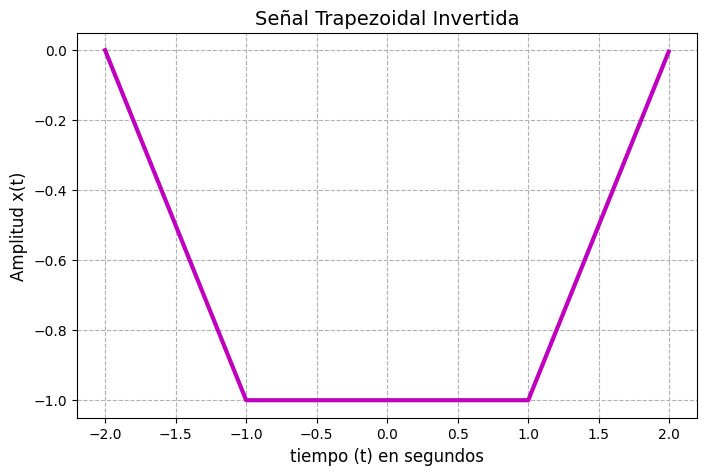

/tmp/ipython-input-13-451602417.py:39: RuntimeWarning: invalid value encountered in divide
  coeffs_Cn = -(2 * (np.cos(vector_n * np.pi / 2) - np.cos(vector_n * np.pi))) / ((np.pi**2) * (vector_n**2))


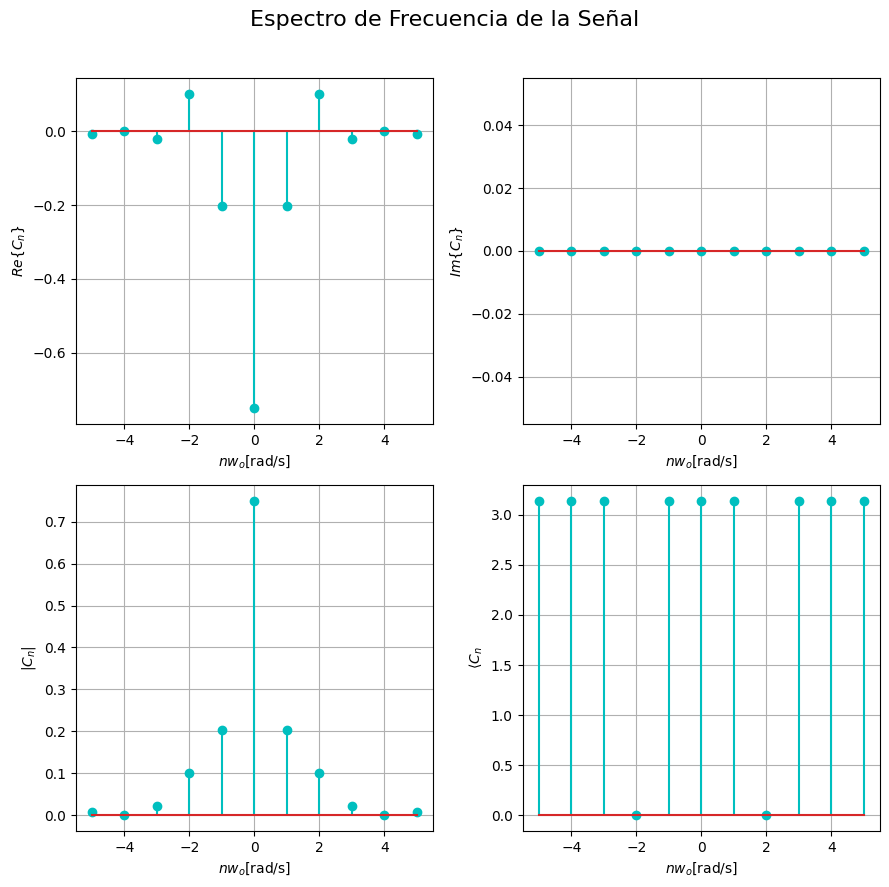

In [13]:
import numpy as np
import matplotlib.pyplot as plt

#--- Cambios: Nombres de variables ---
amplitud = 1
d2_lim = 2
d1_lim = 1
periodo = 2 * d2_lim
Fo = 1 / periodo
Fs = 1000 * Fo
vector_tiempo = np.arange(-periodo/2, periodo/2, 1/Fs)
num_muestras = len(vector_tiempo)

# La función
def funcion_trapecio(x, a, b, c, d):
    positive_trap = np.maximum(0, np.minimum((x - a) / (b - a), np.minimum(1, (d - x) / (d - c))))
    return -positive_trap

senal_xt = amplitud * funcion_trapecio(vector_tiempo, -d2_lim, -d1_lim, d1_lim, d2_lim)

#---  Estilo de graficación  ---
plt.figure(figsize=(8, 5)) # Añadido para controlar tamaño
plt.plot(vector_tiempo, senal_xt, 'm', linewidth=3) # Color magenta y línea más delgada
plt.grid(linestyle='--') # Rejilla con líneas discontinuas
plt.xlabel("tiempo (t) en segundos", fontsize=12)
plt.ylabel("Amplitud x(t)", fontsize=12)
plt.title("Señal Trapezoidal Invertida", fontsize=14)
plt.show()


# El cálculo del espectro no cambia en su lógica
N = 5
wo = 2 * np.pi / periodo
phin = np.zeros((num_muestras, 2*N + 1), np.complex128)
for n in range(-N, N + 1, 1):
    phin[:, n + N] = np.exp(1j * n * wo * vector_tiempo)

vector_n = np.linspace(-N, N, 2 * N + 1)
coeffs_Cn = -(2 * (np.cos(vector_n * np.pi / 2) - np.cos(vector_n * np.pi))) / ((np.pi**2) * (vector_n**2))
coeffs_Cn[N] = -3/4

#---  Estilo de graficación usando subplots de forma orientada a objetos ---
fig, axs = plt.subplots(2, 2, figsize=(9, 9)) # Se crean los ejes de una vez
fig.suptitle("Espectro de Frecuencia de la Señal", fontsize=16)

axs[0, 0].stem(vector_n, np.real(coeffs_Cn), 'c') # Color cian
axs[0, 0].set_ylabel(r'$Re\{C_n\}$')

axs[0, 1].stem(vector_n, np.imag(coeffs_Cn), 'c')
axs[0, 1].set_ylabel(r'$Im\{C_n\}$')

axs[1, 0].stem(vector_n, abs(coeffs_Cn), 'c')
axs[1, 0].set_ylabel(r'$|C_n|$')

axs[1, 1].stem(vector_n, np.angle(coeffs_Cn), 'c')
axs[1, 1].set_ylabel(r'$\langle C_n$')

for ax in axs.flat:
    ax.set_xlabel(r'$nw_o$[rad/s]')
    ax.grid(True)

fig.tight_layout(rect=[0, 0, 1, 0.96]) # Ajuste para el supertítulo
plt.show()

---
### Código 2: Reconstrucción Interactiva con la Serie de Fourier 🎛️

Este código implementa una herramienta interactiva para demostrar visualmente cómo una señal puede ser reconstruida (sintetizada) a partir de la suma de sus componentes de frecuencia.

#### ¿Cómo Funciona?

1.  **Función Principal**: El código se centra en la función `reconstruccion_interactiva`, que toma como argumento el `num_armonicos` a utilizar para la reconstrucción.

2.  **Síntesis de Fourier**: Dentro de la función, la línea `senal_reconstruida = phin[:, indices].dot(coeffs_Cn[indices])` realiza la **Serie de Fourier Inversa**. En la práctica, multiplica la forma de onda de cada armónico (`phin`) por su respectivo coeficiente de fuerza (`coeffs_Cn`) y suma todos los resultados. El resultado es la `senal_reconstruida`.

3.  **Cálculo del Error**: Para cuantificar la calidad de la aproximación, se calcula el **error relativo** (`error_relativo`). Este valor se basa en el **Teorema de Parseval** y representa el porcentaje de la energía total de la señal que *no* fue capturado por los armónicos utilizados en la suma.

4.  **Widget Interactivo**: La magia ocurre con la función `interact`. Esta crea automáticamente un **deslizador (slider)** vinculado al parámetro `num_armonicos` de la función. Al mover el deslizador, la función se vuelve a ejecutar con el nuevo valor, y el gráfico se actualiza en tiempo real, mostrando cómo la `senal_reconstruida` se acerca a la original a medida que se agregan más armónicos. Se usa un **f-string** para mostrar el título, que es la sintaxis moderna en Python para formatear texto.


In [14]:
from ipywidgets import interact, IntSlider

Px = 2/3


def reconstruccion_interactiva(num_armonicos=1):
    indices = np.arange(N - num_armonicos, N + num_armonicos + 1)

    error_relativo = 1 - np.sum(abs(coeffs_Cn[indices])**2) / Px

    # La reconstrucción es la misma lógicamente
    senal_reconstruida = phin[:, indices].dot(coeffs_Cn[indices])

    plt.plot(vector_tiempo, senal_reconstruida.real, color='darkorange', label='$x_e(t)$', linestyle='--') # Naranja y línea discontinua
    plt.plot(vector_tiempo, senal_xt, color='blue', label='x(t)') # Original en azul

    #--- Cambio: Usando f-string para el título (más moderno que %) ---
    plt.title(f'$E_r$ = {100*error_relativo:.2f}%', fontsize=16)

    plt.xlabel('t [s]')
    plt.ylabel('x(t)')
    plt.grid(True)
    plt.legend()
    plt.show()
    return

#--- Cambio: Nombre de la variable en el widget ---
interact(reconstruccion_interactiva, num_armonicos=(1, N, 1));

interactive(children=(IntSlider(value=1, description='num_armonicos', max=5, min=1), Output()), _dom_classes=(…


---
### Código 3: Animación Detallada del Proceso de Síntesis de Fourier 🎬

Este script genera una animación completa y detallada que visualiza el proceso de reconstrucción de la señal, mostrando no solo el resultado final, sino cada paso intermedio.

#### ¿Cómo Funciona?

1.  **Función de Animación**: El corazón del script es la función `generar_cuadro_animacion`, que define qué se debe dibujar en cada **cuadro (`n_frame`)** del video.

2.  **Proceso por Cuadro**: Para cada cuadro de la animación, la función realiza lo siguiente:
    * **Actualiza el Título**: Muestra en el título principal cuántos armónicos se están utilizando en ese instante.
    * **Visualiza el Espectro**: En el primer panel, resalta en rojo los coeficientes del espectro que se están incluyendo en la suma para ese cuadro específico.
    * **Muestra los Componentes**: Los siguientes dos paneles grafican las formas de onda de los componentes sinusoidales que se están agregando en ese paso.
    * **Grafica la Reconstrucción**: El panel principal muestra tres líneas: la señal original (negra), la señal reconstruida (`xe_anim`) como la suma acumulada hasta ese cuadro (azul), y la señal de error entre ambas (verde). El título de este panel muestra el error numérico, que disminuye a medida que avanza la animación.

3.  **Ensamblaje del Video**: La línea `anim = animation.FuncAnimation(...)` es la que orquesta todo el proceso. Llama repetidamente a `generar_cuadro_animacion` (una vez por cada valor en `frames`) y une todos los gráficos resultantes en una sola animación fluida. El comando `rc('animation', html='jshtml')` asegura que la animación se pueda reproducir directamente en el entorno de Colab.

In [15]:
from matplotlib import animation, rc
from IPython.display import HTML

fig, ax = plt.subplots(2, 3, figsize=(13, 6))


def generar_cuadro_animacion(n_frame):
    # Limpieza de los ejes
    for axis in ax.flat:
        axis.clear()

    fig.suptitle(f"Animación de la Reconstrucción - Usando {n_frame} Armónicos", fontsize=16)

    # Espectro
    indices_anim = np.arange(N - n_frame, N + n_frame + 1)
    ax[0, 0].stem(vector_n, abs(coeffs_Cn), linefmt='grey', markerfmt='Dk') # Estilo de tallo diferente
    ax[0, 0].stem(vector_n[indices_anim], abs(coeffs_Cn[indices_anim]), linefmt='r-', markerfmt='o')
    ax[0, 0].set_ylabel(r'$|C_n|$')

    # Componentes espectrales
    ce_anim = phin[:, indices_anim].dot(np.diag(coeffs_Cn[indices_anim]))
    ax[0, 1].plot(vector_tiempo, np.real(ce_anim), color='purple') # Color púrpura
    ax[0, 1].set_ylabel('$Re\{c_n\phi_n(t)\}$')

    ax[0, 2].plot(vector_tiempo, np.imag(ce_anim), color='purple')
    ax[0, 2].set_ylabel('$Im\{c_n\phi_n(t)\}$')

    # Reconstrucción
    er_anim = 1 - np.sum(abs(coeffs_Cn[indices_anim])**2) / Px
    xe_anim = phin[:, indices_anim].dot(coeffs_Cn[indices_anim])
    et_anim = senal_xt - xe_anim

    ax[1, 1].plot(vector_tiempo, senal_xt, 'k', linewidth=3, label='$x(t)$', alpha=0.5) # Original en negro semitransparente
    ax[1, 1].plot(vector_tiempo, xe_anim.real, color='b', label='$x_e(t)$')
    ax[1, 1].plot(vector_tiempo, et_anim.real, color='g', linestyle='-.', label='$e(t)$') # Estilo de línea diferente

    ax[1, 1].set_title(f'$E_r$={100*er_anim:.2f}[%]')
    ax[1, 1].set_xlabel('t[s]')
    ax[1, 1].set_ylabel('x(t)')
    ax[1, 1].legend(loc='upper right')

    ax[1, 0].axis('off')
    ax[1, 2].axis('off')
    plt.subplots_adjust(wspace=0.5, hspace=0.7)


anim = animation.FuncAnimation(fig, generar_cuadro_animacion, frames=range(N + 1), blit=False)
rc('animation', html='jshtml')
plt.close() # Para no mostrar la figura base estática
anim

<Figure size 640x480 with 0 Axes>